In [1]:
# Phase 19 – Statistical Analysis | Cell 1: Setup + collect samples

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DIR  = PROJECT / "outputs" / "phase19"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 19 – Statistical Analysis | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

candidates = [
    PROJECT / "outputs" / "phase9" / "tables" / "phase9_full_benchmark.csv",
    PROJECT / "outputs" / "phase9" / "tables" / "benchmark_full.csv",
    PROJECT / "outputs" / "phase11" / "tables" / "phase11r_full_benchmark.csv",
    PROJECT / "outputs" / "phase11" / "tables" / "phase11_full_benchmark.csv",
    PROJECT / "outputs" / "phase13" / "tables" / "phase13_summary_ranking.csv",
    PROJECT / "outputs" / "phase13" / "tables" / "phase13_episode_metrics.csv",
    PROJECT / "outputs" / "phase18" / "tables" / "phase18_ablation_raw.csv",
    PROJECT / "outputs" / "phase18" / "tables" / "phase18_official_vs_retrain_raw.csv",
    PROJECT / "outputs" / "phase12" / "tables" / "phase12_strong_coupling_summary.csv",
]

loaded = {}
for p in candidates:
    if p.exists():
        df = pd.read_csv(p)
        loaded[p.name] = df
        print(f"  [OK] {p.name:45s} {df.shape}")
    else:
        print(f"  [MISS] {p.name}")

# Build a unified long sample table if possible
frames = []

# phase18 ablation raw has mean_reward per variant/shock
if "phase18_ablation_raw.csv" in loaded:
    a = loaded["phase18_ablation_raw.csv"].copy()
    a["source"] = "phase18_ablation"
    a["group"] = a["variant"].astype(str)
    a["value"] = a["mean_reward"]
    frames.append(a[["source", "series", "group", "value"]])

if "phase18_official_vs_retrain_raw.csv" in loaded:
    b = loaded["phase18_official_vs_retrain_raw.csv"].copy()
    b["source"] = "phase18_retrain"
    b["group"] = b["model_set"].astype(str)
    b["value"] = b["mean_reward"]
    if "series" not in b.columns:
        b["series"] = "standard"
    frames.append(b[["source", "series", "group", "value"]])

if "phase13_summary_ranking.csv" in loaded:
    c = loaded["phase13_summary_ranking.csv"].copy()
    c["source"] = "phase13"
    if "architecture" in c.columns and "policy" in c.columns:
        c["group"] = c["architecture"].astype(str) + "+" + c["policy"].astype(str)
    elif "architecture" in c.columns:
        c["group"] = c["architecture"].astype(str)
    else:
        c["group"] = "phase13"
    valcol = "mean_reward" if "mean_reward" in c.columns else c.select_dtypes("number").columns[0]
    c["value"] = c[valcol]
    if "series" not in c.columns:
        c["series"] = "all"
    frames.append(c[["source", "series", "group", "value"]])

# phase9 / phase11 benchmarks if present
for key in list(loaded.keys()):
    if "benchmark" in key.lower() and key.startswith("phase"):
        d = loaded[key].copy()
        d["source"] = key
        gcol = "algorithm" if "algorithm" in d.columns else ("model" if "model" in d.columns else None)
        if gcol is None:
            continue
        d["group"] = d[gcol].astype(str)
        if "level" in d.columns:
            d["group"] = d["group"] + "|" + d["level"].astype(str)
        if "series" in d.columns:
            d["group"] = d["group"] + "|" + d["series"].astype(str)
        elif "series" not in d.columns:
            d["series"] = "na"
        vcol = "mean_reward" if "mean_reward" in d.columns else None
        if vcol is None:
            continue
        d["value"] = d[vcol]
        if "series" not in d.columns:
            d["series"] = "na"
        frames.append(d[["source", "series", "group", "value"]])

if not frames:
    raise RuntimeError("No usable result tables found for statistical tests.")

data = pd.concat(frames, ignore_index=True)
data = data.dropna(subset=["value"])
data.to_csv(OUT_TAB / "phase19_samples_long.csv", index=False)
print(f"\nUnified samples: {len(data)} rows | groups={data['group'].nunique()} | sources={data['source'].nunique()}")
print(data.groupby("source")["group"].nunique())
print("Cell 1 completed successfully.")

Phase 19 – Statistical Analysis | Cell 1
Timestamp : 2026-10-06 10:39:31
  [MISS] phase9_full_benchmark.csv
  [MISS] benchmark_full.csv
  [OK] phase11r_full_benchmark.csv                   (18, 17)
  [MISS] phase11_full_benchmark.csv
  [OK] phase13_summary_ranking.csv                   (10, 19)
  [MISS] phase13_episode_metrics.csv
  [OK] phase18_ablation_raw.csv                      (64, 8)
  [OK] phase18_official_vs_retrain_raw.csv           (12, 7)
  [OK] phase12_strong_coupling_summary.csv           (8, 10)

Unified samples: 104 rows | groups=34 | sources=4
source
phase11r_full_benchmark.csv    18
phase13                         5
phase18_ablation                8
phase18_retrain                 3
Name: group, dtype: int64
Cell 1 completed successfully.


Phase 19 – Cell 2: Statistical tests
Focus sources: ['phase18_ablation', 'phase18_retrain', 'phase13']

=== phase18_ablation | groups=8 | n=64 ===
  ANOVA p=5.889e-88 | Kruskal p=6.18e-10 | Friedman p=5.4230695808281155e-09

=== phase18_retrain | groups=3 | n=12 ===
  ANOVA p=0 | Kruskal p=0.004087 | Friedman p=0.018315638888734186

=== phase13 | groups=5 | n=10 ===
  ANOVA p=6.713e-05 | Kruskal p=0.06829 | Friedman p=0.0915781944436709

=== Normality (fraction groups normal @0.05 Shapiro) ===
source
phase13             0.00
phase18_ablation    0.25
phase18_retrain     1.00
Name: normal_shapiro_0.05, dtype: float64

=== Significant pairwise (Bonferroni) count ===
source
phase13             0
phase18_ablation    0
phase18_retrain     0
Name: significant_0.05_bonf, dtype: int64

=== Top |Cohen's d| pairs ===
          source         group1         group2     cohens_d  cliffs_delta  p_bonferroni
phase18_ablation          no_SR      no_StageI  5328.089139           1.0       0.21875
phase1

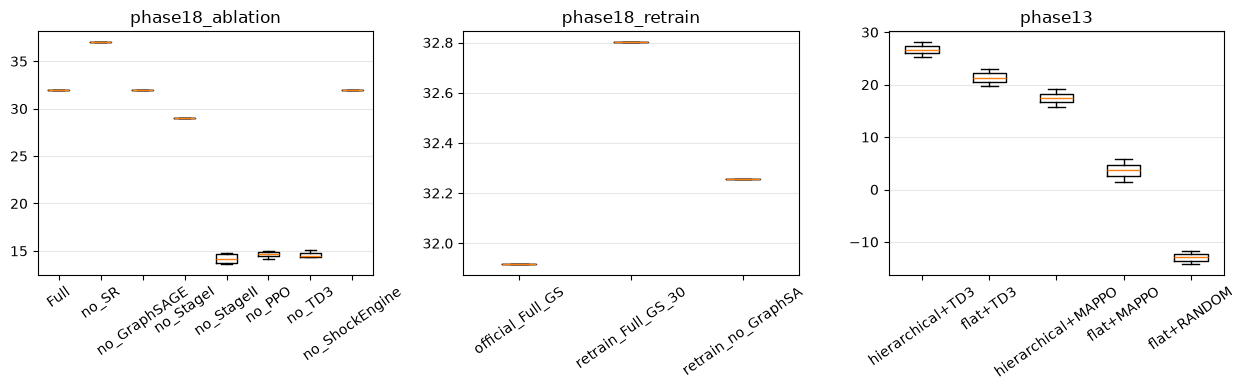


Cell 2 completed successfully.
PHASE 19 COMPLETED.


In [5]:
# Phase 19 – Cell 2: Normality, group tests, post-hoc, effect sizes

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

from scipy import stats

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase19" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase19" / "figures"

print("=" * 60)
print("Phase 19 – Cell 2: Statistical tests")
print("=" * 60)

data = pd.read_csv(OUT_TAB / "phase19_samples_long.csv")

# Focus sets with enough groups
FOCUS_SOURCES = [
    "phase18_ablation",
    "phase18_retrain",
    "phase13",
]
FOCUS_SOURCES = [s for s in FOCUS_SOURCES if s in set(data["source"])]
if not FOCUS_SOURCES:
    FOCUS_SOURCES = sorted(data["source"].unique())[:3]

print("Focus sources:", FOCUS_SOURCES)

# ---------- helpers ----------
def shapiro_safe(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, np.nan
    if len(x) > 5000:
        x = np.random.default_rng(0).choice(x, size=5000, replace=False)
    try:
        return stats.shapiro(x)
    except Exception:
        return np.nan, np.nan

def ks_normal_safe(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, np.nan
    mu, sig = np.mean(x), np.std(x, ddof=1)
    if sig < 1e-12:
        return np.nan, np.nan
    return stats.kstest(x, "norm", args=(mu, sig))

def cohens_d(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1) * va + (nb - 1) * vb) / max(na + nb - 2, 1))
    if pooled < 1e-12:
        return 0.0
    return float((np.mean(a) - np.mean(b)) / pooled)

def hedges_g(a, b):
    d = cohens_d(a, b)
    n = len(a) + len(b)
    if n <= 2:
        return d
    corr = 1 - 3 / (4 * n - 9)
    return float(d * corr)

def cliffs_delta(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    # efficient approx for moderate n
    gt = 0; lt = 0
    for x in a:
        gt += np.sum(x > b)
        lt += np.sum(x < b)
    return float((gt - lt) / (len(a) * len(b)))

norm_rows = []
group_rows = []
post_rows = []
effect_rows = []

for src in FOCUS_SOURCES:
    sub = data[data.source == src].copy()
    groups = sorted(sub["group"].unique())
    print(f"\n=== {src} | groups={len(groups)} | n={len(sub)} ===")

    # Normality per group
    for g in groups:
        x = sub.loc[sub.group == g, "value"].values
        W, p_s = shapiro_safe(x)
        D, p_k = ks_normal_safe(x)
        norm_rows.append({
            "source": src, "group": g, "n": len(x),
            "shapiro_W": W, "shapiro_p": p_s,
            "ks_D": D, "ks_p": p_k,
            "normal_shapiro_0.05": bool(p_s >= 0.05) if p_s == p_s else False,
        })

    # arrays for group tests
    samples = [sub.loc[sub.group == g, "value"].values for g in groups]
    samples = [s for s in samples if len(s) >= 1]
    if len(samples) < 2:
        continue

    # ANOVA (parametric)
    try:
        F, p_anova = stats.f_oneway(*samples)
    except Exception:
        F, p_anova = np.nan, np.nan

    # Kruskal-Wallis
    try:
        H, p_kw = stats.kruskal(*samples)
    except Exception:
        H, p_kw = np.nan, np.nan

    # Friedman needs paired equal-length; skip if not aligned
    p_fried = np.nan
    try:
        lengths = [len(s) for s in samples]
        if len(set(lengths)) == 1 and lengths[0] >= 2 and len(samples) >= 2:
            # shape (n_blocks, n_groups) — here treat index as block if equal n
            mat = np.vstack(samples).T
            stat_f, p_fried = stats.friedmanchisquare(*[mat[:, i] for i in range(mat.shape[1])])
        else:
            stat_f = np.nan
    except Exception:
        stat_f, p_fried = np.nan, np.nan

    group_rows.append({
        "source": src,
        "n_groups": len(samples),
        "ANOVA_F": F, "ANOVA_p": p_anova,
        "Kruskal_H": H, "Kruskal_p": p_kw,
        "Friedman_stat": stat_f if "stat_f" in dir() else np.nan,
        "Friedman_p": p_fried,
    })
    print(f"  ANOVA p={p_anova:.4g} | Kruskal p={p_kw:.4g} | Friedman p={p_fried}")

    # Pairwise Wilcoxon + Bonferroni + effect sizes
    pairs = list(combinations(groups, 2))
    pvals = []
    pair_meta = []
    for g1, g2 in pairs:
        a = sub.loc[sub.group == g1, "value"].values
        b = sub.loc[sub.group == g2, "value"].values
        # Wilcoxon requires equal length for paired; use Mann-Whitney as robust fallback
        try:
            if len(a) == len(b) and len(a) >= 3:
                stat_w, p_w = stats.wilcoxon(a, b, zero_method="wilcox", alternative="two-sided")
                test = "wilcoxon"
            else:
                stat_w, p_w = stats.mannwhitneyu(a, b, alternative="two-sided")
                test = "mannwhitneyu"
        except Exception:
            stat_w, p_w, test = np.nan, np.nan, "failed"
        pvals.append(p_w)
        pair_meta.append((g1, g2, a, b, stat_w, p_w, test))

    pvals = np.array([p if p == p else 1.0 for p in pvals], dtype=float)
    # Bonferroni
    p_bonf = np.minimum(pvals * len(pvals), 1.0)
    # Nemenyi-like rank note: full Nemenyi needs ranks matrix; report Bonferroni primary

    for i, (g1, g2, a, b, stat_w, p_w, test) in enumerate(pair_meta):
        post_rows.append({
            "source": src,
            "group1": g1,
            "group2": g2,
            "test": test,
            "stat": stat_w,
            "p_raw": p_w,
            "p_bonferroni": float(p_bonf[i]),
            "significant_0.05_bonf": bool(p_bonf[i] < 0.05),
            "cohens_d": cohens_d(a, b),
            "hedges_g": hedges_g(a, b),
            "cliffs_delta": cliffs_delta(a, b),
            "mean1": float(np.mean(a)),
            "mean2": float(np.mean(b)),
        })
        effect_rows.append({
            "source": src, "group1": g1, "group2": g2,
            "cohens_d": cohens_d(a, b),
            "hedges_g": hedges_g(a, b),
            "cliffs_delta": cliffs_delta(a, b),
        })

norm_df = pd.DataFrame(norm_rows)
group_df = pd.DataFrame(group_rows)
post_df = pd.DataFrame(post_rows)
eff_df = pd.DataFrame(effect_rows)

norm_df.to_csv(OUT_TAB / "phase19_normality.csv", index=False)
group_df.to_csv(OUT_TAB / "phase19_group_tests.csv", index=False)
post_df.to_csv(OUT_TAB / "phase19_posthoc_effects.csv", index=False)

print("\n=== Normality (fraction groups normal @0.05 Shapiro) ===")
if len(norm_df):
    print(norm_df.groupby("source")["normal_shapiro_0.05"].mean())

print("\n=== Significant pairwise (Bonferroni) count ===")
if len(post_df):
    print(post_df.groupby("source")["significant_0.05_bonf"].sum())

# Top effect sizes
if len(post_df):
    top = post_df.reindex(post_df["cohens_d"].abs().sort_values(ascending=False).index).head(12)
    print("\n=== Top |Cohen's d| pairs ===")
    print(top[["source", "group1", "group2", "cohens_d", "cliffs_delta", "p_bonferroni"]].to_string(index=False))

# plots
# FIX plot section only (replace the plotting block at end of Cell 2)

fig, axes = plt.subplots(1, min(3, len(FOCUS_SOURCES)), figsize=(4.2 * min(3, len(FOCUS_SOURCES)), 4))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
for ax, src in zip(axes, FOCUS_SOURCES):
    sub = data[data.source == src]
    vc = sub["group"].value_counts().head(8).index
    plot_df = sub[sub.group.isin(vc)]
    order = list(vc)
    data_plot = [plot_df.loc[plot_df.group == g, "value"].values for g in order]
    bp = ax.boxplot(data_plot, vert=True)
    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels([str(g)[:18] for g in order], rotation=35)
    ax.set_title(src)
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase19_group_boxplots.png", dpi=150)
plt.show()

print("\nCell 2 completed successfully.")
print("PHASE 19 COMPLETED.")

Phase 19 – Cell 3: Episode-level statistics
Full         | BankingCrisis/Moderate done
no_StageI    | BankingCrisis/Moderate done
no_StageII   | BankingCrisis/Moderate done
no_PPO       | BankingCrisis/Moderate done
no_TD3       | BankingCrisis/Moderate done
Random       | BankingCrisis/Moderate done
Full         | BankingCrisis/Severe done
no_StageI    | BankingCrisis/Severe done
no_StageII   | BankingCrisis/Severe done
no_PPO       | BankingCrisis/Severe done
no_TD3       | BankingCrisis/Severe done
Random       | BankingCrisis/Severe done
Full         | Recession/Moderate done
no_StageI    | Recession/Moderate done
no_StageII   | Recession/Moderate done
no_PPO       | Recession/Moderate done
no_TD3       | Recession/Moderate done
Random       | Recession/Moderate done
Full         | DebtCrisis/Severe done
no_StageI    | DebtCrisis/Severe done
no_StageII   | DebtCrisis/Severe done
no_PPO       | DebtCrisis/Severe done
no_TD3       | DebtCrisis/Severe done
Random       | DebtCrisis/Se

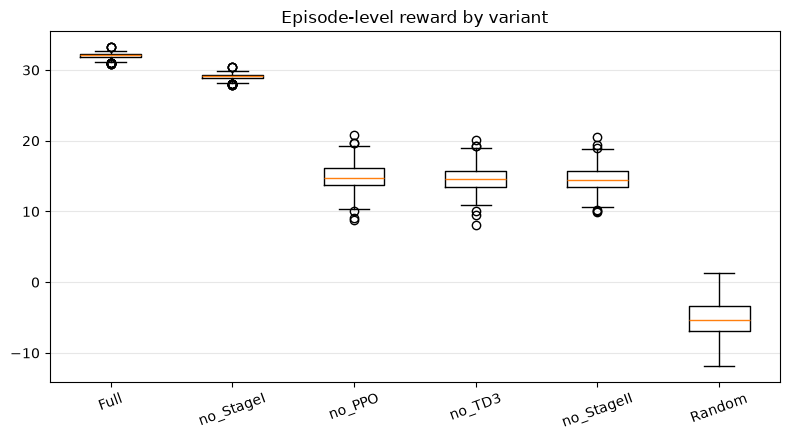


Cell 3 completed successfully.
STAT LIMITATION ADDRESSED.


In [6]:
# Phase 19 – Cell 3: Episode-level samples + proper pairwise tests

from pathlib import Path
import numpy as np
import pandas as pd
import sys
from itertools import combinations
from scipy import stats
from stable_baselines3 import PPO, TD3
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
P9 = PROJECT / "outputs" / "phase9" / "models"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase19" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase19" / "figures"

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv

print("=" * 60)
print("Phase 19 – Cell 3: Episode-level statistics")
print("=" * 60)

N_EP = 30          # enough for pairwise power
SEEDS = [0, 1, 2]
SERIES = "standard"
SHOCKS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Severe"),
]

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

ppo_path = P9 / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    ppo_path = P9 / "PPO_moderate.zip"
ppo = PPO.load(str(ppo_path))
td3_path = P11 / "TD3_standard_r.zip"
if not td3_path.exists():
    td3_path = P11 / "TD3_standard.zip"
td3 = TD3.load(str(td3_path))

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def act_ppo(obs, env):
    a, _ = ppo.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    return (np.pad(a, (0, max(0, adim - a.size)))[:adim])

def act_td3(obs, env):
    a, _ = td3.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        tax, sub, rate, qe, credit, risk = a[:6]
        a = np.array([tax, 0.5*sub+0.3*qe, 0.4*qe+0.3*risk, 0.5*credit+0.2*rate], dtype=np.float32)
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

def run_variant(variant, shock_type, severity, seed):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", shock_type=None, severity=None,
        shock_series=SERIES, seed=seed,
    )
    obs, _ = env.reset(seed=seed)
    R = 0.0
    STAGE1, STAGE2 = 10, 30

    def step(a):
        nonlocal obs, R
        obs, r, term, trunc, _ = env.step(a)
        R += float(r)
        return term or trunc

    if variant == "Full":
        for _ in range(STAGE1):
            if step(act_ppo(obs, env)): break
        if hasattr(env, "apply_shock"):
            env.apply_shock(shock_type, severity, SERIES); obs = rebuild_obs(env)
        for _ in range(STAGE2):
            if step(act_td3(obs, env)): break

    elif variant == "no_StageII":
        for _ in range(STAGE1):
            if step(act_ppo(obs, env)): break
        if hasattr(env, "apply_shock"):
            env.apply_shock(shock_type, severity, SERIES); obs = rebuild_obs(env)
        for _ in range(STAGE2):
            if step(env.action_space.sample()): break

    elif variant == "no_StageI":
        if hasattr(env, "apply_shock"):
            env.apply_shock(shock_type, severity, SERIES); obs = rebuild_obs(env)
        for _ in range(STAGE1 + STAGE2):
            if step(act_td3(obs, env)): break

    elif variant == "no_PPO":
        for _ in range(STAGE1):
            if step(env.action_space.sample()): break
        if hasattr(env, "apply_shock"):
            env.apply_shock(shock_type, severity, SERIES); obs = rebuild_obs(env)
        for _ in range(STAGE2):
            if step(act_td3(obs, env)): break

    elif variant == "no_TD3":
        for _ in range(STAGE1):
            if step(act_ppo(obs, env)): break
        if hasattr(env, "apply_shock"):
            env.apply_shock(shock_type, severity, SERIES); obs = rebuild_obs(env)
        for _ in range(STAGE2):
            if step(env.action_space.sample()): break

    elif variant == "Random":
        if hasattr(env, "apply_shock"):
            env.apply_shock(shock_type, severity, SERIES); obs = rebuild_obs(env)
        for _ in range(STAGE1 + STAGE2):
            if step(env.action_space.sample()): break

    return R, get_sr(env)

VARIANTS = ["Full", "no_StageI", "no_StageII", "no_PPO", "no_TD3", "Random"]
rows = []
for st, sev in SHOCKS:
    for v in VARIANTS:
        for seed in SEEDS:
            for ep in range(N_EP):
                sid = seed * 10000 + ep
                r, sr = run_variant(v, st, sev, sid)
                rows.append({
                    "variant": v, "shock_type": st, "severity": sev,
                    "seed": seed, "ep": ep, "reward": r, "sr_end": sr,
                })
        print(f"{v:12s} | {st}/{sev} done")

ep_df = pd.DataFrame(rows)
ep_df.to_csv(OUT_TAB / "phase19_episode_samples.csv", index=False)
print("Episode samples:", len(ep_df))

# --- stats on episode samples ---
def cohens_d(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    pooled = np.sqrt(((len(a)-1)*np.var(a, ddof=1) + (len(b)-1)*np.var(b, ddof=1)) / max(len(a)+len(b)-2, 1))
    return float((np.mean(a)-np.mean(b))/(pooled+1e-12))

def cliffs_delta(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    gt = sum(np.sum(x > b) for x in a)
    lt = sum(np.sum(x < b) for x in a)
    return float((gt-lt)/(len(a)*len(b)))

# group tests overall (reward)
samples = [ep_df.loc[ep_df.variant == v, "reward"].values for v in VARIANTS]
H, p_kw = stats.kruskal(*samples)
F, p_an = stats.f_oneway(*samples)
print(f"\nKruskal p={p_kw:.4g} | ANOVA p={p_an:.4g}")

# pairwise vs Full
post = []
full = ep_df.loc[ep_df.variant == "Full", "reward"].values
for v in VARIANTS:
    if v == "Full":
        continue
    x = ep_df.loc[ep_df.variant == v, "reward"].values
    # paired-style: same n → wilcoxon if equal length else mannwhitney
    try:
        if len(x) == len(full):
            stat, p = stats.wilcoxon(full, x)
            test = "wilcoxon"
        else:
            stat, p = stats.mannwhitneyu(full, x, alternative="two-sided")
            test = "mannwhitneyu"
    except Exception:
        stat, p, test = np.nan, np.nan, "fail"
    post.append({
        "group1": "Full", "group2": v, "test": test, "stat": stat, "p_raw": p,
        "cohens_d_Full_minus_v": cohens_d(full, x),
        "cliffs_delta": cliffs_delta(full, x),
        "mean_Full": float(np.mean(full)), "mean_v": float(np.mean(x)),
        "n": len(x),
    })

post = pd.DataFrame(post)
post["p_bonferroni"] = np.minimum(post["p_raw"] * len(post), 1.0)
post["sig_bonf_0.05"] = post["p_bonferroni"] < 0.05
post.to_csv(OUT_TAB / "phase19_episode_posthoc_vs_full.csv", index=False)
print("\n=== Pairwise vs Full (episode-level) ===")
print(post.to_string(index=False))

# summary
summ = ep_df.groupby("variant", as_index=False).agg(
    mean_reward=("reward", "mean"), std_reward=("reward", "std"),
    mean_sr=("sr_end", "mean"), n=("reward", "count")
).sort_values("mean_reward", ascending=False)
summ.to_csv(OUT_TAB / "phase19_episode_summary.csv", index=False)
print("\n=== Summary ===")
print(summ.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
order = summ["variant"].tolist()
data_plot = [ep_df.loc[ep_df.variant == v, "reward"].values for v in order]
ax.boxplot(data_plot, vert=True)
ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels(order, rotation=20)
ax.set_title("Episode-level reward by variant")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase19_episode_boxplots.png", dpi=150)
plt.show()

print("\nCell 3 completed successfully.")
print("STAT LIMITATION ADDRESSED.")